In [ ]:
# === Importación de librerías ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


Cargar `ecoenergy-consumption-data.csv` en Google Colab y verificar que estén presentes los campos esperados: `client_id`, `client_name`, `region`, `contract_type`, `consumption_kwh`, `billing_date`, `co2_emissions`, `cost_per_kwh`, `total_cost` y `renewable_energy_percentage`.


In [ ]:
# === Importación de archivos ===
from google.colab import files
uploaded = files.upload()
archivo=list(uploaded.keys())[0]
print(f'Archivo {archivo} cargado correctamente.')

Saving ecoenergy-consumption-data.csv to ecoenergy-consumption-data.csv
Archivo ecoenergy-consumption-data.csv cargado correctamente.


In [ ]:
# === Confirmar que están los datos esperados ===
df_raw = pd.read_csv(archivo)
display(df_raw.head(10))

,client_id,client_name,region,contract_type,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
0,1,"Hood, Cooper and Burke",Centro,Residencial,3423,2024-03-23,276.7400,0.1300,444.9900,89
1,2,"Hamilton, White and Smith",Este,Comercial,7714,2024-08-05,1805.7900,0.1500,1157.1000,37
2,3,Keith Group,Sur,Residencial,3745,2024-02-04,726.3400,0.1400,524.3000,69
3,4,Jackson-Strong,Oeste,Comercial,8151,2024-06-21,130.0500,0.1800,1467.1800,29
4,5,"Coleman, Ayala and Sullivan",Este,Comercial,3137,2024-02-16,961.6700,0.2400,752.8800,50
5,6,"Robinson, Mclaughlin and Mitchell",Norte,Comercial,8849,2024-04-27,1023.0100,0.2100,1858.2900,8
6,7,Rios-Johnson,Centro,Residencial,2218,2024-03-01,317.1100,0.2100,465.7800,10
7,8,"Robinson, Gutierrez and Daniels",Oeste,Residencial,5349,2024-05-10,558.0100,0.1300,695.3700,29
8,9,Wallace Ltd,Este,Residencial,8663,2024-05-01,1595.4400,0.1500,1299.4500,48
9,10,"Richardson, Jenkins and Boyd",Centro,Residencial,4058,2024-07-26,232.7600,0.1400,568.1200,92


Inspeccionar la estructura del conjunto de datos, incluyendo número de filas, nombres de columnas, tipos de datos, valores faltantes, filas duplicadas, regiones únicas, tipos de contrato únicos y el rango de fechas de facturación.

In [ ]:
# == Tipos de datos y valores NO NULOS ===
print('Información del DF')
print()
df_raw.info(show_counts=True)

Información del DF

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   client_id                    10000 non-null  int64  
 1   client_name                  10000 non-null  object 
 2   region                       10000 non-null  object 
 3   contract_type                10000 non-null  object 
 4   consumption_kwh              10000 non-null  int64  
 5   billing_date                 10000 non-null  object 
 6   co2_emissions                10000 non-null  float64
 7   cost_per_kwh                 10000 non-null  float64
 8   total_cost                   10000 non-null  float64
 9   renewable_energy_percentage  10000 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


In [ ]:
# === Valores NULOS ===
nulos =df_raw.isnull().sum() #sumamos los NA
nulos_pct=(nulos/len(df_raw)*100).round(2) #calculamos % nulos
nulos_resumen=pd.DataFrame({'nulos':nulos,'porcentaje':nulos_pct})
nulos_resumen.sort_values(by='nulos',ascending=False)
print('Valores faltantes por columna')
display(nulos_resumen)

Valores faltantes por columna


,nulos,porcentaje
client_id,0,0.0000
client_name,0,0.0000
region,0,0.0000
contract_type,0,0.0000
consumption_kwh,0,0.0000
billing_date,0,0.0000
co2_emissions,0,0.0000
cost_per_kwh,0,0.0000
total_cost,0,0.0000
renewable_energy_percentage,0,0.0000


Convertir `billing_date` a un formato de fecha válido y asegurar que los campos de consumo, emisiones, coste y porcentaje renovable estén almacenados como valores numéricos adecuados para análisis.

In [ ]:
# === Formato "billing_date" ===
df_raw['billing_date'] = pd.to_datetime(df_raw['billing_date'])
df_raw['mes'] = df_raw['billing_date'].dt.to_period('M')
df_raw['trimestre'] = df_raw['billing_date'].dt.to_period('Q')
df_raw['num_mes'] = df_raw['billing_date'].dt.month

display(df_raw)

,client_id,client_name,region,contract_type,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage,mes,trimestre,num_mes
0,1,"Hood, Cooper and Burke",Centro,Residencial,3423,2024-03-23,276.7400,0.1300,444.9900,89,2024-03,2024Q1,3
1,2,"Hamilton, White and Smith",Este,Comercial,7714,2024-08-05,1805.7900,0.1500,1157.1000,37,2024-08,2024Q3,8
2,3,Keith Group,Sur,Residencial,3745,2024-02-04,726.3400,0.1400,524.3000,69,2024-02,2024Q1,2
3,4,Jackson-Strong,Oeste,Comercial,8151,2024-06-21,130.0500,0.1800,1467.1800,29,2024-06,2024Q2,6
4,5,"Coleman, Ayala and Sullivan",Este,Comercial,3137,2024-02-16,961.6700,0.2400,752.8800,50,2024-02,2024Q1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Murray-Cole,Norte,Comercial,6289,2024-07-30,926.3400,0.1900,1194.9100,79,2024-07,2024Q3,7
9996,9997,"Rollins, Obrien and Brown",Norte,Residencial,8017,2024-05-30,1487.2400,0.1800,1443.0600,56,2024-05,2024Q2,5
9997,9998,Carter-Smith,Este,Comercial,1693,2024-06-18,1903.0800,0.1300,220.0900,5,2024-06,2024Q2,6
9998,9999,Ballard Ltd,Sur,Residencial,7215,2024-10-19,1823.0000,0.2200,1587.3000,36,2024-10,2024Q4,10


In [ ]:
# === Verificar valores numéricos adecuados para análisis ===

#valores negativos
col_num =['consumption_kwh', 'co2_emissions', 'cost_per_kwh', 'total_cost', 'renewable_energy_percentage']
for col in col_num:
  neg = (df_raw[col] < 0).sum()
  print(f'Valores negativos en {col}: {neg}')

#rango porcentaje renobable q no sea inferior a 0 ni superior a 100
pct_inv = df_raw[(df_raw['renewable_energy_percentage'] > 0) | (df_raw['renewable_energy_percentage'] > 100) ]
print(f'\nPorcentajes renovables fuera de rango [0, 100]: {len(pct_inv)}')
print(f'\nDatos listos para análisis')

Valores negativos en consumption_kwh: 0
Valores negativos en co2_emissions: 0
Valores negativos en cost_per_kwh: 0
Valores negativos en total_cost: 0
Valores negativos en renewable_energy_percentage: 0

Porcentajes renovables fuera de rango [0, 100]: 9899

Datos listos para análisis


Identificar problemas de calidad de datos tales como valores faltantes, registros duplicados, fechas inválidas, valores numéricos negativos o irreales, categorías inconsistentes y observaciones inusuales.

In [ ]:
# == valores faltantes, duplicados, tipos de datos, valores únicos, rangos de fechas ==
print(' == Valores faltantes ==')
print(df_raw.isnull().sum())

print('\n == Registros duplicados ==')
print(df_raw.duplicated().sum())

print('\n == Tipos de datos ==')
print(df_raw.dtypes)

print('\n == Valores únicos ==')
print('Regiones:', df_raw['region'].unique().tolist())
print('Contratos:', df_raw['contract_type'].unique().tolist())

print ('\n == Rango de fechas == ')
print(df_raw['billing_date'].min())
print(df_raw['billing_date'].max())


 == Valores faltantes ==
client_id                      0
client_name                    0
region                         0
contract_type                  0
consumption_kwh                0
billing_date                   0
co2_emissions                  0
cost_per_kwh                   0
total_cost                     0
renewable_energy_percentage    0
mes                            0
trimestre                      0
num_mes                        0
dtype: int64

 == Registros duplicados ==
0

 == Tipos de datos ==
client_id                               int64
client_name                            object
region                                 object
contract_type                          object
consumption_kwh                         int64
billing_date                   datetime64[ns]
co2_emissions                         float64
cost_per_kwh                          float64
total_cost                            float64
renewable_energy_percentage             int64
mes                

In [ ]:
# == detección de outliers por IQR ==
for col in col_num:
  q1, q3 = df_raw[col].quantile([0.25, 0.75])
  iqr = q3 - q1
  iqr_bajo = q1 - 1.5 * iqr
  iqr_alto = q3 + 1.5 * iqr
  outliers= df_raw[(df_raw[col] < iqr_bajo) | (df_raw[col] > iqr_alto)]
  print(f'Outliers en {col}: {len(outliers)} outliers ({100*len(outliers)/len(df_raw):.1f})')

Outliers en consumption_kwh: 0 outliers (0.0)
Outliers en co2_emissions: 0 outliers (0.0)
Outliers en cost_per_kwh: 0 outliers (0.0)
Outliers en total_cost: 0 outliers (0.0)
Outliers en renewable_energy_percentage: 0 outliers (0.0)


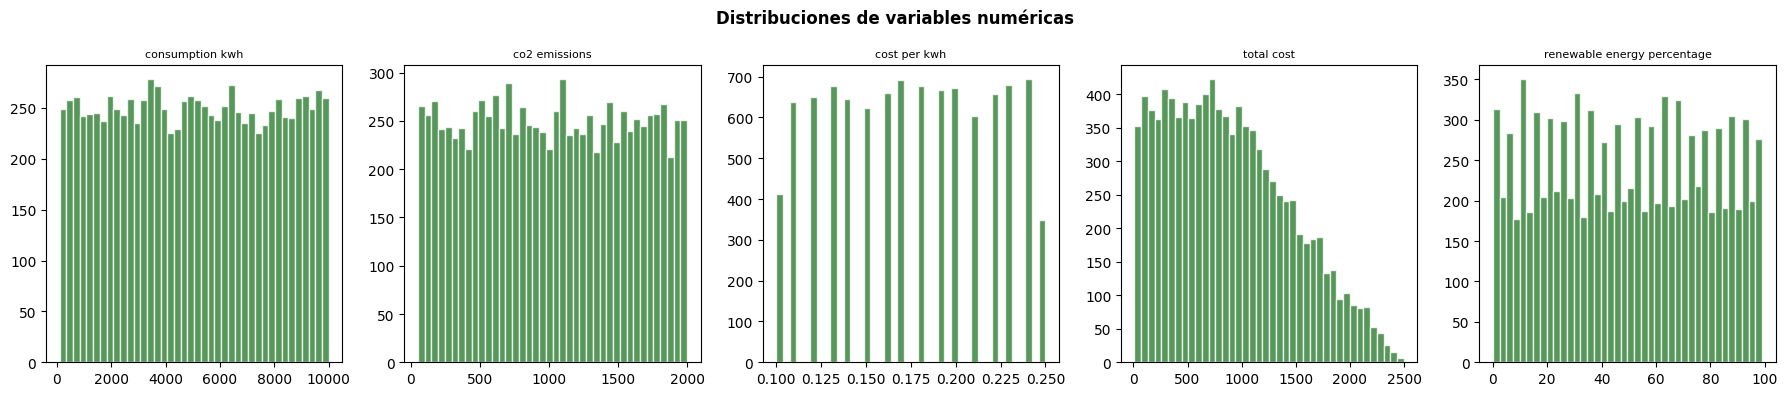

In [ ]:
# == Histograma de distribución para visualización ==
fig, axes = plt.subplots(1, 5, figsize=(18,4))
for ax, col in zip(axes, col_num):
  ax.hist(df_raw[col], bins=40, color='#2E7D32', alpha=0.8, edgecolor='white')
  ax.set_title(col.replace('_',' '), fontsize=8)
  ax.set_xlabel('')
plt.suptitle('Distribuciones de variables numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

Calcular estadísticas descriptivas para las principales variables numéricas, como consumo energético, emisiones de CO₂, coste por kWh, coste total y porcentaje de energía renovable.

In [ ]:
# == Estadísticas descriptivas ==
desc = df_raw[col_num].describe().round(2)
desc.loc['skewness'] = df_raw[col_num].skew().round(2)
print(desc)

          consumption_kwh  co2_emissions  cost_per_kwh  total_cost  \
count          10000.0000     10000.0000    10000.0000  10000.0000   
mean            5051.0900      1019.7000        0.1700    886.0200   
std             2867.3000       563.4300        0.0400    565.8300   
min              100.0000        50.0400        0.1000     10.0000   
25%             2588.0000       536.4100        0.1400    418.4600   
50%             5032.5000      1020.2400        0.1800    818.6200   
75%             7542.2500      1510.8400        0.2100   1276.4900   
max             9999.0000      1999.9400        0.2500   2497.5000   
skewness           0.0100         0.0100       -0.0100      0.4700   

          renewable_energy_percentage  
count                      10000.0000  
mean                          49.1100  
std                           28.8100  
min                            0.0000  
25%                           24.0000  
50%                           49.0000  
75%                

Analizar patrones de consumo según región y tipo de contrato para identificar segmentos con mayor consumo, mayores emisiones, costes superiores o mayor adopción de energía renovable.

In [ ]:
# === Análisis por región y tipo de contrato ==
#por región
region = df_raw.groupby('region').agg(
    registros= ('client_id', 'count'),
    consumo_medio= ('consumption_kwh', 'mean'),
    emisiones_medio= ('co2_emissions', 'mean'),
    coste_medio= ('total_cost', 'mean'),
    renovable_medio= ('renewable_energy_percentage', 'mean')
).round(1).sort_values('consumo_medio', ascending=False)
print(' == Por región ==')
display(region)
print()
#por contrato
contrato = df_raw.groupby('contract_type').agg(
    registros= ('client_id', 'count'),
    consumo_medio= ('consumption_kwh', 'mean'),
    emisiones_medio= ('co2_emissions', 'mean'),
    coste_medio= ('total_cost', 'mean'),
    renovable_medio= ('renewable_energy_percentage', 'mean')
).round(1)
print('\n == Por contrato ==')
print(contrato)

 == Por región ==


,registros,consumo_medio,emisiones_medio,coste_medio,renovable_medio
region,,,,,
Norte,2052,5114.7000,1026.1000,896.5000,49.5000
Sur,2010,5076.9000,1019.6000,893.2000,48.7000
Centro,2040,5027.3000,1011.8000,889.6000,49.1000
Oeste,1893,5018.6000,1029.7000,873.3000,48.6000
Este,2005,5015.0000,1011.9000,876.4000,49.7000




 == Por contrato ==
               registros  consumo_medio  emisiones_medio  coste_medio  \
contract_type                                                           
Comercial           5093      5046.0000        1015.2000     889.5000   
Residencial         4907      5056.3000        1024.3000     882.4000   

               renovable_medio  
contract_type                   
Comercial              49.3000  
Residencial            48.9000  


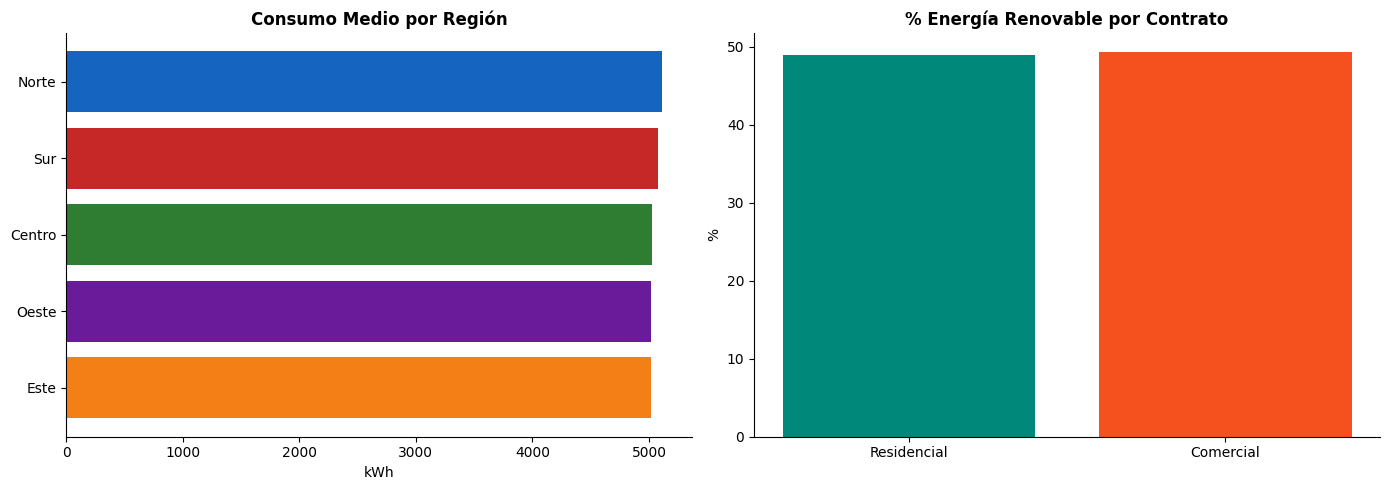

In [ ]:
# == Visualización ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_reg = {'Centro':'#2E7D32','Norte':'#1565C0','Este':'#F57F17','Sur':'#C62828','Oeste':'#6A1B9A'}
region_ordenado = region.reset_index().sort_values('consumo_medio')
axes[0].barh(region_ordenado['region'], region_ordenado['consumo_medio'],
             color=[colores_reg[r] for r in region_ordenado['region']])
axes[0].set_title('Consumo Medio por Región', fontweight='bold')
axes[0].set_xlabel('kWh')

axes[1].bar(['Residencial','Comercial'],
            [contrato.loc['Residencial','renovable_medio'], contrato.loc['Comercial','renovable_medio']],
            color=['#00897B','#F4511E'])
axes[1].set_title('% Energía Renovable por Contrato', fontweight='bold')
axes[1].set_ylabel('%')
for ax in axes:
    for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Evaluar relaciones entre variables numéricas, especialmente `consumption_kwh`, `co2_emissions`, `cost_per_kwh`, `total_cost` y `renewable_energy_percentage`.

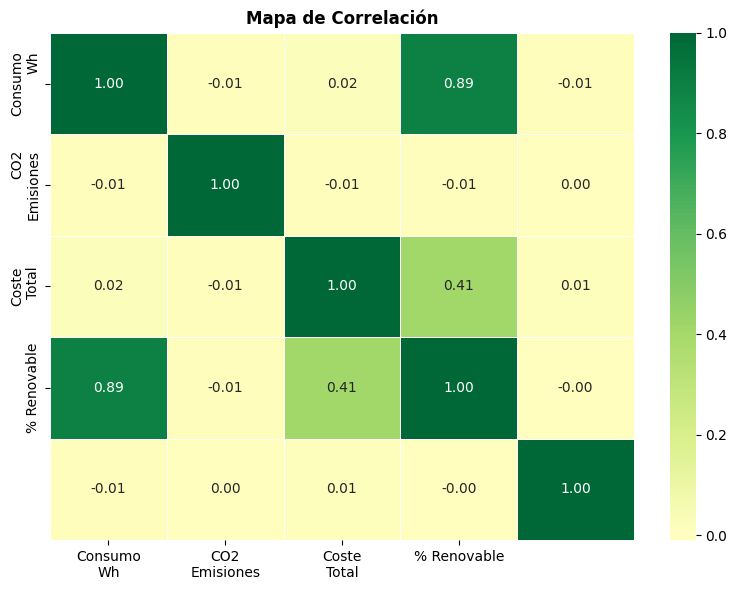

Correlación consumo vs coste total: 0.893
Correlación consumo vs CO2: -0.007
Correlación renovable vs CO2: 0.001


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
corr = df_raw[col_num].corr()
etiquetas = ['Consumo\nWh', 'CO2\nEmisiones', 'Coste\nTotal', '% Renovable']
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=etiquetas, yticklabels=etiquetas, ax=ax,
            linewidths=0.5, annot_kws={'size':10})
ax.set_title('Mapa de Correlación', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlación consumo vs coste total:', corr.loc['consumption_kwh','total_cost'].round(3))
print('Correlación consumo vs CO2:', corr.loc['consumption_kwh','co2_emissions'].round(3))
print('Correlación renovable vs CO2:', corr.loc['renewable_energy_percentage','co2_emissions'].round(3))

Detectar y revisar valores atípicos en consumo, emisiones, coste por kWh y coste total usando métodos estadísticos o visuales claros como diagramas de caja, histogramas, análisis de rango intercuartílico o umbrales percentílicos.

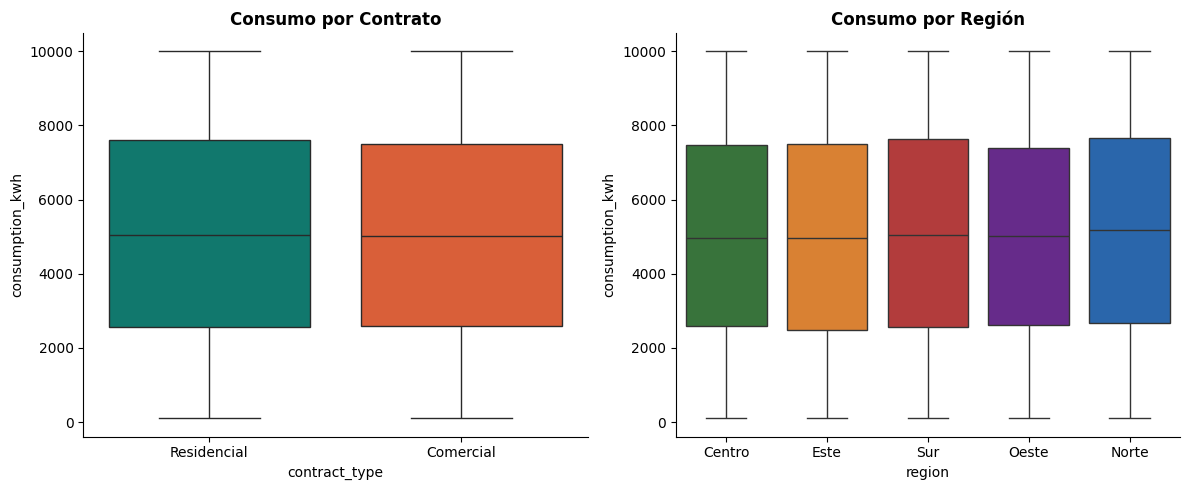

In [ ]:
# == Outliers visual (residencial/comercial) (diagrama de cajas)==
fig, axes = plt.subplots(1, 2, figsize=(12,5))
colores = {'Residencial':'#00897B', 'Comercial':'#F4511E'}
sns.boxplot(data=df_raw, x='contract_type', y='consumption_kwh', palette=colores, ax=axes[0])
axes[0].set_title('Consumo por Contrato', fontweight='bold')
sns.boxplot(data=df_raw, x='region', y='consumption_kwh',
            palette={'Centro':'#2E7D32','Norte':'#1565C0','Este':'#F57F17','Sur':'#C62828','Oeste':'#6A1B9A'},
            ax=axes[1])
axes[1].set_title('Consumo por Región', fontweight='bold')
for ax in axes:
  for spine in ['top', 'right']:ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Analizar patrones temporales usando `billing_date`, agrupando registros por mes, trimestre u otro periodo adecuado según la granularidad del conjunto de datos.

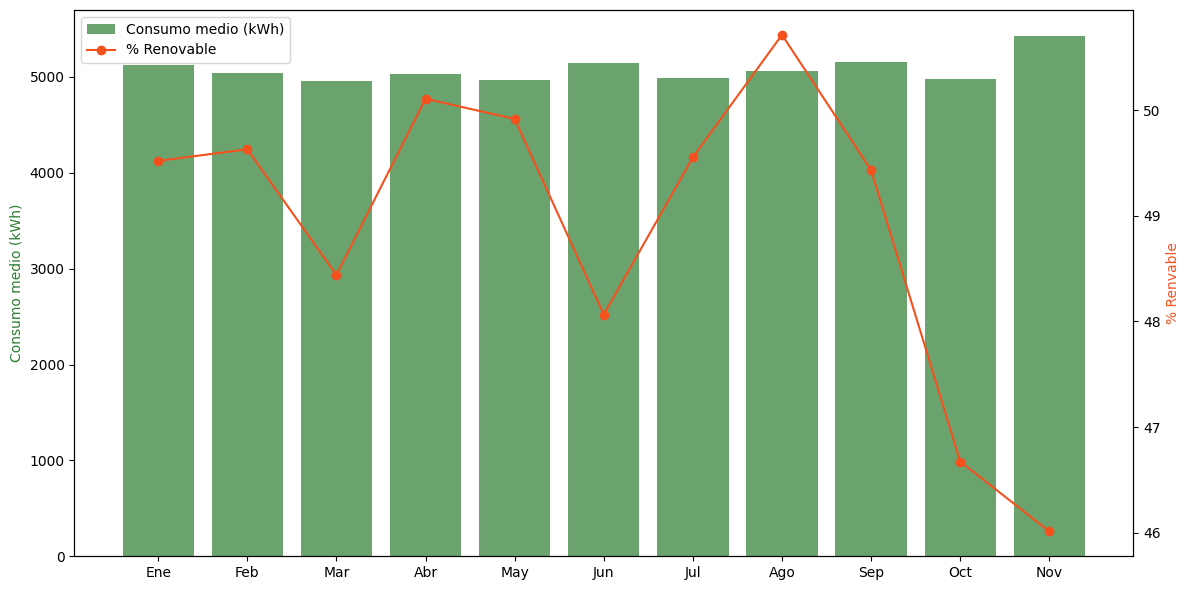

In [ ]:
# == Análisis temporal ==
mensual = df_raw.groupby('num_mes').agg(
    consumo=('consumption_kwh', 'mean'),
    emisiones=('co2_emissions', 'mean'),
    renovable=('renewable_energy_percentage', 'mean'),
    coste=('total_cost', 'mean')
)
meses_esp=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
mensual['mes'] = [meses_esp[m-1] for m in mensual.index]

fig, ax1=plt.subplots(figsize=(12,6))
ax1.bar(mensual['mes'], mensual['consumo'], color='#2D7D32', alpha=0.7, label='Consumo medio (kWh)')
ax1.set_ylabel('Consumo medio (kWh)', color='#2D7D32')
ax2=ax1.twinx()
ax2.plot(mensual['mes'], mensual['renovable'], color='#F4511E', marker='o', label='% Renovable')
ax2.set_ylabel('% Renvable', color='#F4511E')
lines1, labels1=ax1.get_legend_handles_labels()
lines2, labels2=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.show()

Preparar un conjunto de datos limpio o agregado para la creación del panel, asegurando que la estructura sea adecuada para Google Looker Studio.

In [ ]:
# == Exportar dataset limpio ==
OUT_PATH_1 = 'ecoenergy_limpio.csv'

df = df_raw.copy()
df['billing_date'] = df['billing_date'].dt.strftime('%Y-%m-%d')
df.drop(columns=['mes', 'trimestre', 'num_mes'], inplace=True)
df.to_csv('ecoenergy_limpio.csv', index=False)
print(f'Dataset limpio exportado: {len(df):,} filas, {df.shape[1]} columnas')

#agregado mensual por región/contrato para Looker Studie
OUT_PATH_LS='ecoenergy_looker.csv'
df['billing_ym']=pd.to_datetime(df['billing_date']).dt.to_period('M').astype(str)
agg = df.groupby(['billing_ym', 'region', 'contract_type']).agg(
    consumo_total=('consumption_kwh', 'sum'),
    consumo_medio= ('consumption_kwh', 'mean'),
    emisiones_total= ('co2_emissions', 'sum'),
    emisiones_medio= ('co2_emissions', 'mean'),
    total_cost=('total_cost', 'sum'),
    coste_kwh_medio=('cost_per_kwh', 'mean'),
    pct_renovable_medio=('renewable_energy_percentage', 'mean'),
    num_clientes=('client_id', 'count')
).reset_index()
agg.to_csv('ecoenergy_looker.csv', index=False)
print(f'Dataset agregado para Looker Studio exportado: {len(agg)} filas')
agg.head()

Dataset limpio exportado: 10,000 filas, 10 columnas
Dataset agregado para Looker Studio exportado: 110 filas


,billing_ym,region,contract_type,consumo_total,consumo_medio,emisiones_total,emisiones_medio,total_cost,coste_kwh_medio,pct_renovable_medio,num_clientes
0,2024-01,Centro,Comercial,539928,5509.4694,92759.3800,946.5243,96011.2400,0.1750,45.4184,98
1,2024-01,Centro,Residencial,500858,4862.6990,103333.5300,1003.2382,84901.7300,0.1688,47.5728,103
2,2024-01,Este,Comercial,473435,5146.0326,96851.7700,1052.7366,80898.7800,0.1720,52.4130,92
3,2024-01,Este,Residencial,486008,5282.6957,93757.9300,1019.1079,81430.9200,0.1645,48.3696,92
4,2024-01,Norte,Comercial,605327,5356.8761,116884.8400,1034.3791,102831.9200,0.1721,50.5841,113


In [ ]:
# === Descarga de documentos al ordenador ===
files.download('ecoenergy_limpio.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('ecoenergy_looker.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>